In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('temperature.csv')

In [5]:
df.head()

,record_id,month,day,year,AverageTemperatureFahr,AverageTemperatureUncertaintyFahr,City,country_id,Country,Latitude,Longitude
0,474376,1,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
1,474377,2,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
2,474378,3,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
3,474379,4,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E
4,474380,5,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E


In [2]:
def parse_date(row):
    s=f"{row['year']}-{row['month']}-{row['day']}"
    return datetime.strptime(s, '%Y-%m-%d')

In [7]:
df['Date']=df.apply(parse_date,axis=1)

In [8]:
df.head()

,record_id,month,day,year,AverageTemperatureFahr,AverageTemperatureUncertaintyFahr,City,country_id,Country,Latitude,Longitude,Date
0,474376,1,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E,1853-01-01
1,474377,2,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E,1853-02-01
2,474378,3,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E,1853-03-01
3,474379,4,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E,1853-04-01
4,474380,5,1,1853,NaN,NaN,Auckland,NEW,New Zealand,36.17S,175.03E,1853-05-01


In [9]:
Auckland=df.loc[df['City']=="Auckland"].copy().dropna()
Stokholm=df.loc[df['City']=="Stockholm"].copy().dropna()

In [10]:
Auckland=Auckland[['Date','AverageTemperatureFahr']]
Stokholm=Stokholm[['Date','AverageTemperatureFahr']]

In [11]:
Auckland.set_index(Auckland['Date'],inplace=True)
Auckland.drop('Date',axis=1,inplace=True)
Auckland.columns=['AucklandTemp']

In [12]:
Auckland.head()

,AucklandTemp
Date,
1853-06-01,51.9062
1853-07-01,52.3886
1853-08-01,52.8530
1853-09-01,52.5776
1853-10-01,54.8726


In [13]:
Stokholm.set_index(Stokholm['Date'],inplace=True)
Stokholm.drop('Date',axis=1,inplace=True)
Stokholm.columns=['StokholmTemp']

In [14]:
Stokholm.head()

,StokholmTemp
Date,
1743-11-01,42.8414
1744-04-01,36.8888
1744-05-01,45.1220
1744-06-01,53.1824
1744-07-01,60.0260


In [15]:
joined=Auckland.join(Stokholm,how='outer')

In [16]:
joined.shape

(3155, 2)

In [17]:
joined_part=joined.iloc[-500:].copy()
joined_part.index.freq='MS'

In [18]:
joined_part.isna().sum()

AucklandTemp    1
StokholmTemp    4
dtype: int64

In [19]:
joined_part.interpolate(inplace=True)

In [20]:
joined_part.isna().sum()

AucklandTemp    0
StokholmTemp    0
dtype: int64

<AxesSubplot:xlabel='Date'>

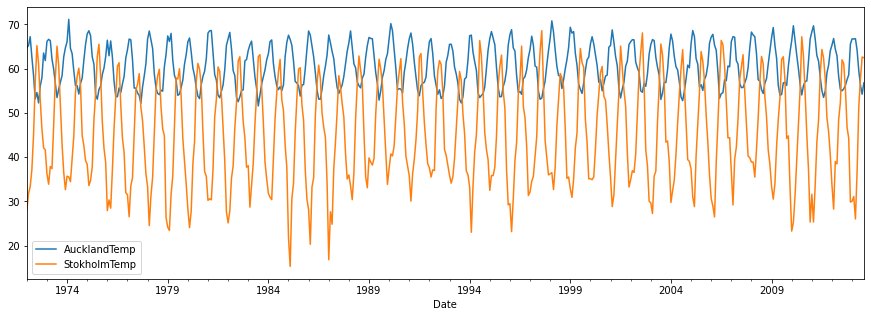

In [21]:
joined_part.plot(figsize=(15,5))

In [25]:
Ntest=12
train=joined_part.iloc[:-Ntest].copy()
test=joined_part.iloc[-Ntest:].copy()

In [26]:
scale_Auckland=StandardScaler()
train['standard_Auckland']=scale_Auckland.fit_transform(train[['AucklandTemp']].to_numpy())
test['standard_Auckland']=scale_Auckland.transform(test[['AucklandTemp']].to_numpy())



In [27]:
scale_Stokhom=StandardScaler()
train['standard_stokholm']=scale_Stokhom.fit_transform(train[['StokholmTemp']].to_numpy())
test['standard_stokholm']=scale_Stokhom.transform(test[['StokholmTemp']].to_numpy())



In [28]:
train.head()

,AucklandTemp,StokholmTemp,standard_Auckland,standard_stokholm
Date,,,,
1972-01-01,64.7312,27.9194,0.912482,-1.491603
1972-02-01,65.2010,31.8020,1.010449,-1.150745
1972-03-01,67.2116,33.3140,1.429716,-1.018004
1972-04-01,62.6378,37.1462,0.475948,-0.681570
1972-05-01,58.4708,44.9906,-0.392990,0.007099


In [29]:
train_idx=joined_part.index<=train.index[-1]
test_idx=joined_part.index>train.index[-1]

In [30]:
joined_part.loc[train_idx,'standard_stokholm']=train['standard_stokholm']
joined_part.loc[test_idx,'standard_stokholm']=test['standard_stokholm']
joined_part.loc[train_idx,'standard_Auckland']=train['standard_Auckland']
joined_part.loc[test_idx,'standard_Auckland']=test['standard_Auckland']

<AxesSubplot:xlabel='Date'>

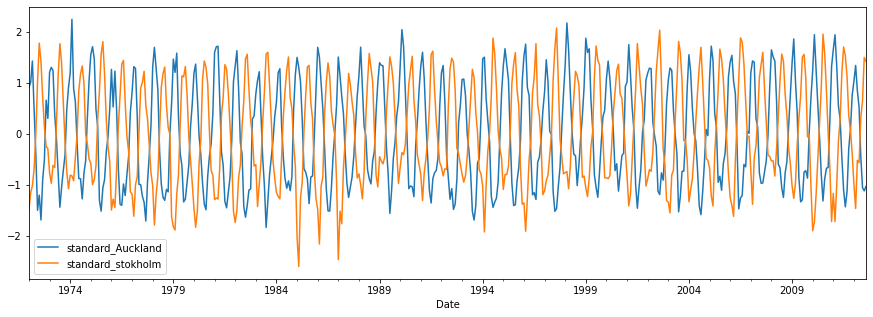

In [31]:
cols=['standard_Auckland','standard_stokholm']
train[cols].plot(figsize=(15,5))

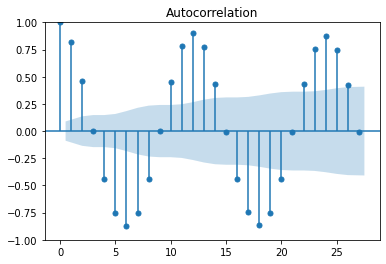

In [27]:
plot_acf(train['standard_Auckland']);

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


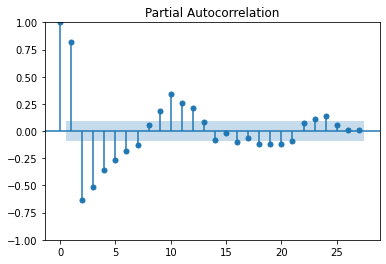

In [28]:
plot_pacf(train['standard_Auckland']);

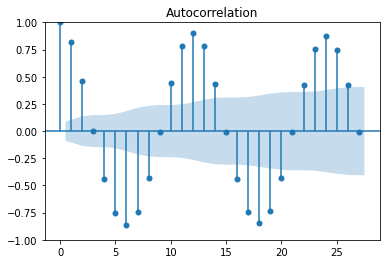

In [29]:
plot_acf(train['standard_stokholm']);

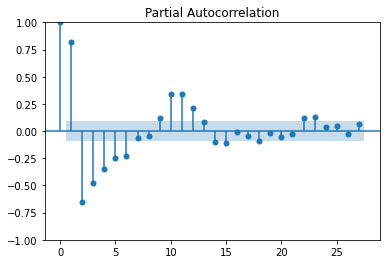

In [30]:
plot_pacf(train['standard_stokholm']);

In [31]:
t0=datetime.now()
model=VARMAX(train[cols],order=(10,10))
res=model.fit(maxiter=100)
print('Duration:',datetime.now()-t0)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Duration: 0:05:15.578673


In [32]:
fcast=res.get_forecast(Ntest)

In [33]:
res.fittedvalues['standard_stokholm']

Date
1972-01-01   -0.007554
1972-02-01   -1.091890
1972-03-01   -0.737909
1972-04-01   -0.607958
1972-05-01    0.014870
                ...   
2012-04-01   -0.236544
2012-05-01    0.336360
2012-06-01    1.134355
2012-07-01    1.361929
2012-08-01    1.438952
Freq: MS, Name: standard_stokholm, Length: 488, dtype: float64

In [34]:
joined_part.loc[train_idx,'train pred stokholm']=res.fittedvalues['standard_stokholm']
joined_part.loc[test_idx,'test pred stokholm']=fcast.predicted_mean['standard_stokholm']



In [35]:
joined_part.head()

,AucklandTemp,StokholmTemp,standard_stokholm,standard_Auckland,train pred stokholm,test pred stokholm
Date,,,,,,
1972-01-01,64.7312,27.9194,-1.491603,0.912482,-0.007554,NaN
1972-02-01,65.2010,31.8020,-1.150745,1.010449,-1.091890,NaN
1972-03-01,67.2116,33.3140,-1.018004,1.429716,-0.737909,NaN
1972-04-01,62.6378,37.1462,-0.681570,0.475948,-0.607958,NaN
1972-05-01,58.4708,44.9906,0.007099,-0.392990,0.014870,NaN


<AxesSubplot:xlabel='Date'>

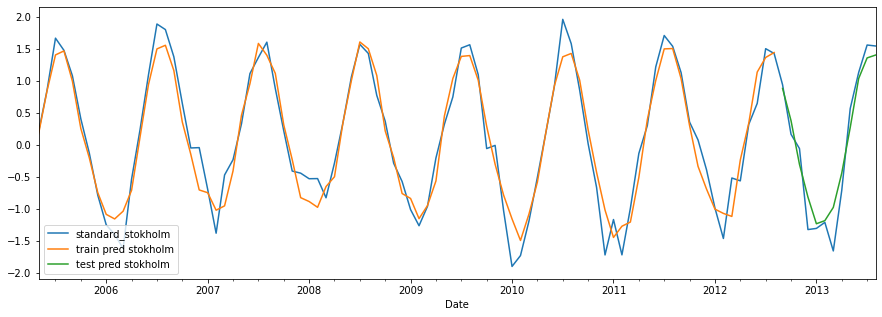

In [41]:
plot_cols=['standard_stokholm','train pred stokholm','test pred stokholm']
joined_part.iloc[-100:][plot_cols].plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

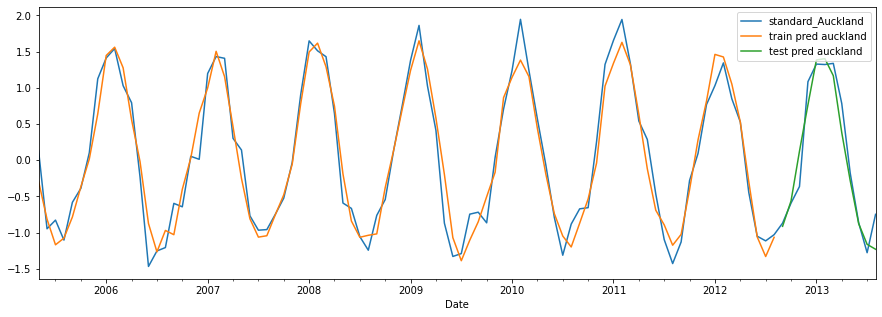

In [42]:
joined_part.loc[train_idx,'train pred auckland']=res.fittedvalues['standard_Auckland']
joined_part.loc[test_idx,'test pred auckland']=fcast.predicted_mean['standard_Auckland']

plot_cols=['standard_Auckland','train pred auckland','test pred auckland']
joined_part.iloc[-100:][plot_cols].plot(figsize=(15,5))

In [134]:
joined_part.head()

,AucklandTemp,StokholmTemp,train pred Acland,test pred Acland,train pred stokholm,test pred stokholm,standard_stokholm,standard_Auckland
Date,,,,,,,,
1972-01-01,64.7312,27.9194,-0.007554,NaN,-0.007554,NaN,-1.491603,0.912482
1972-02-01,65.2010,31.8020,-1.091890,NaN,-1.091890,NaN,-1.150745,1.010449
1972-03-01,67.2116,33.3140,-0.737909,NaN,-0.737909,NaN,-1.018004,1.429716
1972-04-01,62.6378,37.1462,-0.607958,NaN,-0.607958,NaN,-0.681570,0.475948
1972-05-01,58.4708,44.9906,0.014870,NaN,0.014870,NaN,0.007099,-0.392990


In [136]:
y_pred=joined_part.loc[train_idx,'train pred auckland']
y_true=joined_part.loc[train_idx,'standard_Auckland']
print('Auckland Train R^2:',r2_score(y_true,y_pred))

y_pred=joined_part.loc[test_idx,'test pred auckland']
y_true=joined_part.loc[test_idx,'standard_Auckland']
print('Auckland Test R^2:',r2_score(y_true,y_pred))

Auckland Train R^2: 0.9294143701834285
Auckland Test R^2: 0.9286376288823472


In [138]:
y_pred=joined_part.loc[train_idx,'train pred stokholm']
y_true=joined_part.loc[train_idx,'standard_stokholm']
print('Stockholm Train R^2:',r2_score(y_true,y_pred))

y_pred=joined_part.loc[test_idx,'test pred stokholm']
y_true=joined_part.loc[test_idx,'standard_stokholm']
print('Stockholm Test R^2:',r2_score(y_true,y_pred))

Stockholm Train R^2: 0.9247840263661654
Stockholm Test R^2: 0.9311550725004089


VAR

In [32]:
cols=['standard_Auckland','standard_stokholm']
model=VAR(train[cols])

In [33]:
lag_order_results=model.select_order(maxlags=15)
lag_order_results

In [34]:
lag_order_results.selected_orders

{'aic': 12, 'bic': 6, 'hqic': 11, 'fpe': 12}

In [35]:
results=model.fit(maxlags=15,ic='aic')

In [36]:
lag_order=results.k_ar

In [37]:
prior=train.iloc[-lag_order:][cols].to_numpy()
fcast=results.forecast(prior,Ntest)

In [42]:
joined_part.loc[train_idx,'Train Pred Auckland']=\
    results.fittedvalues['standard_Auckland']
joined_part.loc[test_idx,'Test pred Aukland']=\
    fcast[:,0]

<AxesSubplot:xlabel='Date'>

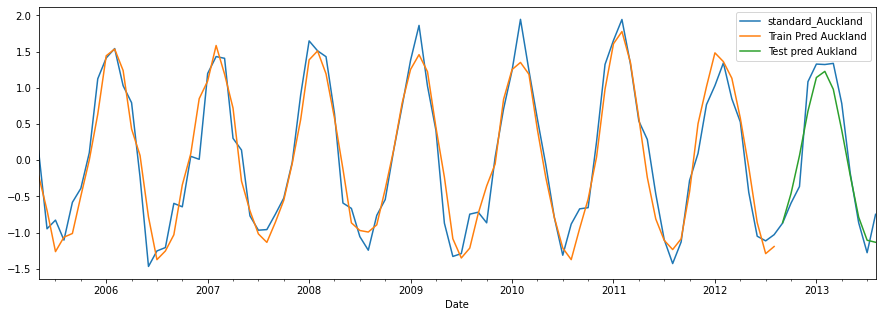

In [45]:
plot_cols=['standard_Auckland','Train Pred Auckland','Test pred Aukland']

joined_part.iloc[-100:][plot_cols].plot(figsize=(15,5))

In [46]:
joined_part.loc[train_idx,'Train Pred Stockholm']=\
    results.fittedvalues['standard_stokholm']
joined_part.loc[test_idx,'Tst pred Stockholm']=\
    fcast[:,1]

<AxesSubplot:xlabel='Date'>

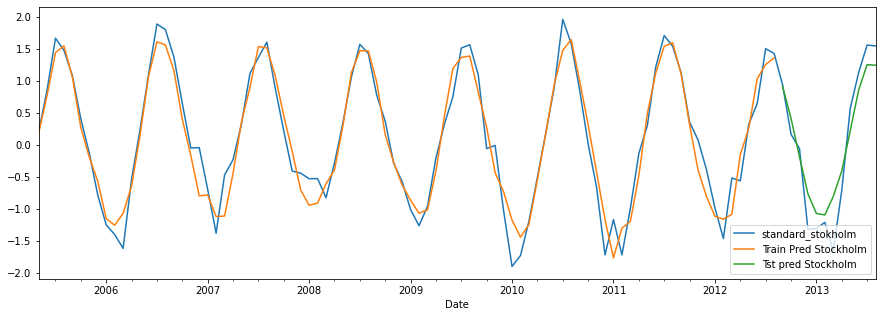

In [47]:
plot_cols=['standard_stokholm','Train Pred Stockholm','Tst pred Stockholm']
joined_part.iloc[-100:][plot_cols].plot(figsize=(15,5))

In [62]:
y_pred=joined_part.loc[train_idx,'Train Pred Auckland']
y_true=joined_part.loc[train_idx,'standard_Auckland']
y_true=y_true[lag_order:]
y_pred=y_pred[lag_order:]
print('Auckland Train R^2:',r2_score(y_true,y_pred))

y_pred=joined_part.loc[test_idx,'Test pred Aukland']
y_true=joined_part.loc[test_idx,'standard_Auckland']
print('Auckland Test R^2:',r2_score(y_true,y_pred))

Auckland Train R^2: 0.921070700106029
Auckland Test R^2: 0.9233643831340896


In [61]:
y_pred=joined_part.loc[train_idx,'Train Pred Stockholm']
y_true=joined_part.loc[train_idx,'standard_stokholm']
y_true=y_true[lag_order:]
y_pred=y_pred[lag_order:]
print('Stockholm Train R^2:',r2_score(y_true,y_pred))

y_pred=joined_part.loc[test_idx,'Tst pred Stockholm']
y_true=joined_part.loc[test_idx,'standard_stokholm']
print('Stockholm Test R^2:',r2_score(y_true,y_pred))

Stockholm Train R^2: 0.9267030553588321
Stockholm Test R^2: 0.8930437688204874


ARIMA Basline

In [64]:
from statsmodels.tsa.arima.model import ARIMA

In [71]:
for col in cols:
    model=ARIMA(train[col],order=(10,0,10))
    res=model.fit()
    fcast=res.get_forecast(Ntest)
    print(f"{col} Train R^2:",r2_score(joined_part.loc[train_idx,col],res.fittedvalues))
    print(f"{col} Test R^2:",r2_score(joined_part.loc[test_idx,col],fcast.predicted_mean))

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


standard_Auckland Train R^2: 0.9213755291915322
standard_Auckland Test R^2: 0.9380563403359977
standard_stokholm Train R^2: 0.9207495225310214
standard_stokholm Test R^2: 0.9483572737279087


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
Econometric

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARIMA

In [43]:
df=pd.read_excel('us_macro_quarterly.xlsx')

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [44]:
df.head()

,Unnamed: 0,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL
0,1957:01,2851.778,8.414363,16.449,3.403333,3.390000,3.096667,3.933333,NaN,27.776667
1,1957:02,2845.453,9.097347,16.553,3.626667,3.540000,3.140000,4.100000,NaN,28.013333
2,1957:03,2873.169,9.042708,16.687,3.926667,3.963333,3.353333,4.233333,NaN,28.263333
3,1957:04,2843.718,8.796834,16.773,3.633333,3.586667,3.310000,4.933333,NaN,28.400000
4,1958:01,2770.000,8.632918,16.978,3.040000,2.160000,1.756667,6.300000,NaN,28.736667


In [45]:
def pars_date(data):
    year,quarter=data.split(':')
    month=(int(quarter)-1)*3+1
    s=f"{year}-{month}"
    return datetime.strptime(s,"%Y-%m")

In [46]:
df['Date']=df['Unnamed: 0'].apply(pars_date)

In [47]:
df.head()

,Unnamed: 0,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL,Date
0,1957:01,2851.778,8.414363,16.449,3.403333,3.390000,3.096667,3.933333,NaN,27.776667,1957-01-01
1,1957:02,2845.453,9.097347,16.553,3.626667,3.540000,3.140000,4.100000,NaN,28.013333,1957-04-01
2,1957:03,2873.169,9.042708,16.687,3.926667,3.963333,3.353333,4.233333,NaN,28.263333,1957-07-01
3,1957:04,2843.718,8.796834,16.773,3.633333,3.586667,3.310000,4.933333,NaN,28.400000,1957-10-01
4,1958:01,2770.000,8.632918,16.978,3.040000,2.160000,1.756667,6.300000,NaN,28.736667,1958-01-01


In [48]:
df.set_index(df['Date'],inplace=True)

In [49]:
df.drop(['Date','Unnamed: 0'],axis=1,inplace=True)

In [50]:
df.index.freq='QS'

<AxesSubplot:xlabel='Date'>

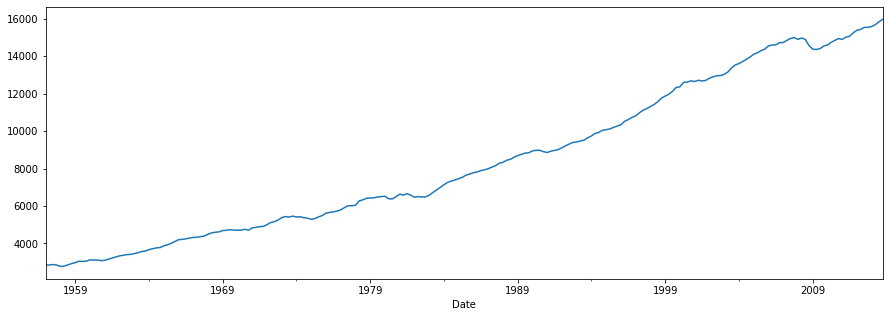

In [51]:
df['GDPC96'].plot(figsize=(15,5))

In [52]:
df['GDPGrowth']=np.log(df['GDPC96']).diff()

In [53]:
df['TSpread']=df['GS10']-df['TB3MS']

<AxesSubplot:xlabel='Date'>

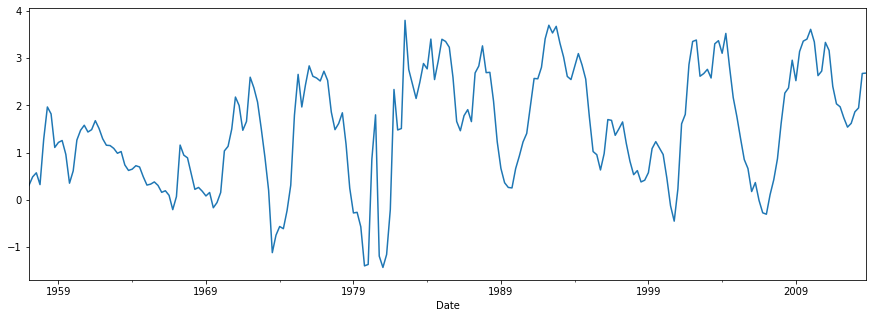

In [54]:
df['TSpread'].plot(figsize=(15,5))

In [55]:
cols=['GDPGrowth','TSpread']

In [56]:
df1=df.iloc[1:][cols].copy()

In [17]:
Ntest=12
train=df1.iloc[:-Ntest].copy()
test=df1.iloc[-Ntest:].copy()

In [18]:
train_idx=df1.index<=train.index[-1]
test_idx=~train_idx

In [21]:
scaler=StandardScaler()
train[cols]=scaler.fit_transform(train)
test[cols]=scaler.transform(test)

In [22]:
df1.loc[train_idx,:]=train
df1.loc[test_idx,:]=test

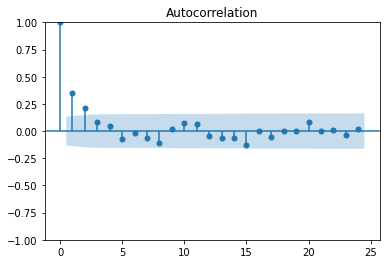

In [23]:
plot_acf(train['GDPGrowth']);

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


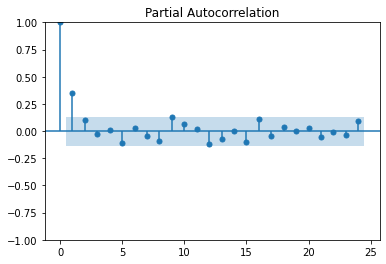

In [24]:
plot_pacf(train['GDPGrowth']);

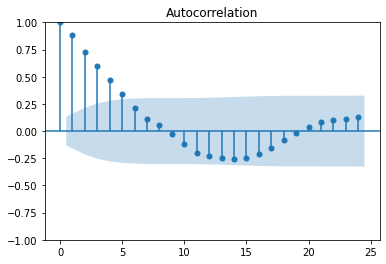

In [23]:
plot_acf(train['TSpread']);

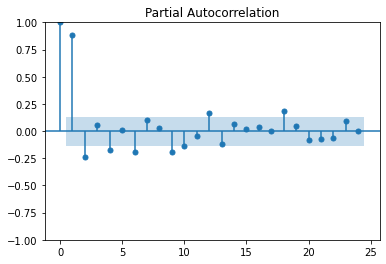

In [24]:
plot_pacf(train['TSpread']);

In [25]:
adfuller(train['GDPGrowth'])

(-7.4466396546255815,
 5.814896580913804e-11,
 1,
 213,
 {'1%': -3.461429147102264,
  '5%': -2.875206950587861,
  '10%': -2.5740544497344002},
 512.854231063742)

In [26]:
adfuller(train['TSpread'])

(-4.001020795475582,
 0.001405175490749354,
 12,
 202,
 {'1%': -3.4631437906252636,
  '5%': -2.8759570379821047,
  '10%': -2.574454682874228},
 246.36949884218734)

In [27]:
p=18
q=1

In [29]:
t0=datetime.now()
model=VARMAX(train,order=(p,q))
res=model.fit(maxiter=100)
print("Duration",datetime.now()-t0)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Duration 0:02:04.615845


In [ ]:
fcast=res.get_forecast(Ntest)

<AxesSubplot:xlabel='Date'>

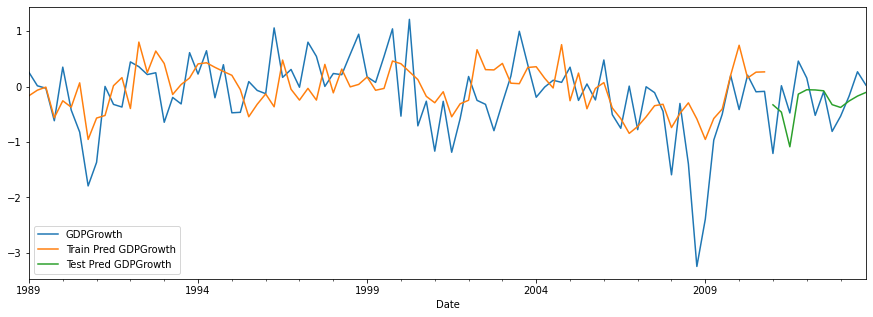

In [58]:
df1.loc[train_idx,"Train Pred GDPGrowth"]=res.fittedvalues['GDPGrowth']
df1.loc[test_idx,"Test Pred GDPGrowth"]=fcast.predicted_mean['GDPGrowth']
plot_cols=['GDPGrowth','Train Pred GDPGrowth','Test Pred GDPGrowth']
df1.iloc[-100:][plot_cols].plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

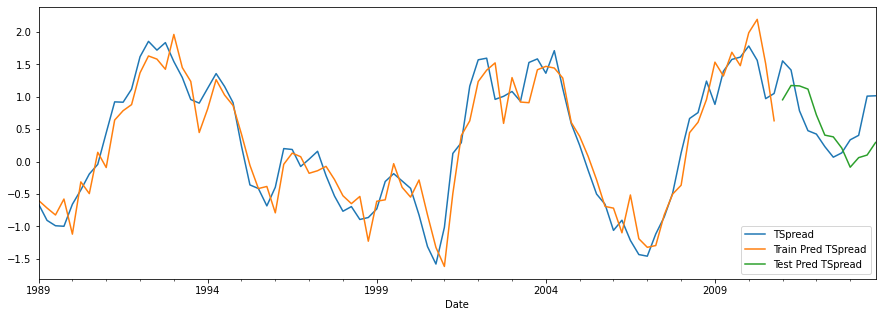

In [59]:
df1.loc[train_idx,"Train Pred TSpread"]=res.fittedvalues['TSpread']
df1.loc[test_idx,"Test Pred TSpread"]=fcast.predicted_mean['TSpread']
plot_cols=['TSpread','Train Pred TSpread','Test Pred TSpread']
df1.iloc[-100:][plot_cols].plot(figsize=(15,5))

In [60]:
for col in cols:
    y_true=df1.loc[train_idx,col]
    y_pred=res.fittedvalues[col]
    print('trian R^2:',r2_score(y_true,y_pred))
    
    y_true=df1.loc[test_idx,col]
    y_pred=fcast.predicted_mean[col]
    print('test R^2:',r2_score(y_true,y_pred))

trian R^2: 0.2763850662939299
test R^2: 0.03472815469286039
trian R^2: 0.8737039169903126
test R^2: -0.052747782111398855


VAR

In [25]:
model=VAR(train)

In [26]:
lag_order_results=model.select_order(maxlags=20)
lag_order_results.selected_orders

{'aic': 10, 'bic': 1, 'hqic': 2, 'fpe': 10}

In [27]:
result=model.fit(maxlags=20,ic='aic')


In [28]:
lag_order=result.k_ar

In [29]:
prior=train.iloc[-lag_order:][cols].to_numpy()
fcast=result.forecast(prior,Ntest)

<AxesSubplot:xlabel='Date'>

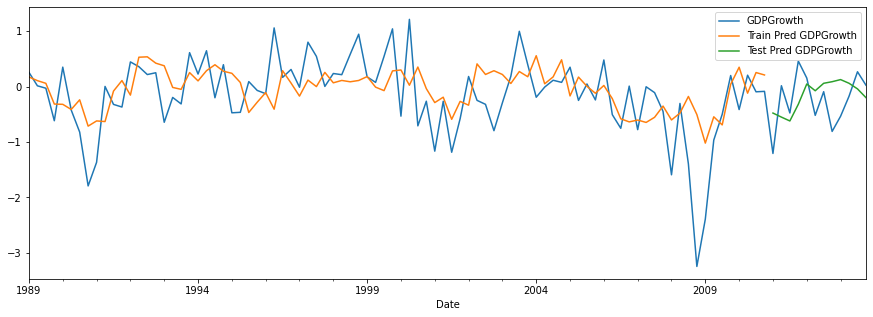

In [31]:
df1.loc[train_idx,"Train Pred GDPGrowth"]=result.fittedvalues['GDPGrowth']
df1.loc[test_idx,"Test Pred GDPGrowth"]=fcast[:,0]
plot_cols=['GDPGrowth','Train Pred GDPGrowth','Test Pred GDPGrowth']
df1.iloc[-100:][plot_cols].plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

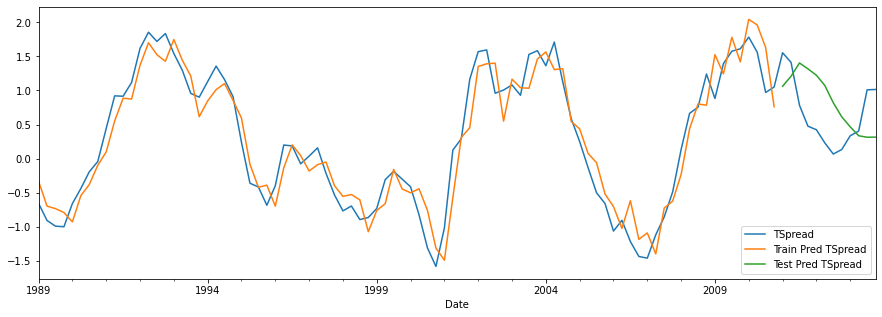

In [32]:
df1.loc[train_idx,"Train Pred TSpread"]=result.fittedvalues['TSpread']
df1.loc[test_idx,"Test Pred TSpread"]=fcast[:,1]
plot_cols=['TSpread','Train Pred TSpread','Test Pred TSpread']
df1.iloc[-100:][plot_cols].plot(figsize=(15,5))

In [36]:
y_pred=df1.loc[train_idx,'Train Pred GDPGrowth']
y_true=df1.loc[train_idx,'GDPGrowth']
y_true=y_true.iloc[lag_order:]
y_pred=y_pred.iloc[lag_order:]
print('trian R^2:',r2_score(y_true,y_pred))


trian R^2: 0.2569812409739455


Granger

In [38]:
from statsmodels.tsa.stattools import grangercausalitytests


In [41]:
df1

,GDPGrowth,TSpread,Train Pred GDPGrowth,Test Pred GDPGrowth,Train Pred TSpread,Test Pred TSpread
Date,,,,,,
1957-04-01,-1.094132,-0.804627,NaN,NaN,NaN,NaN
1957-07-01,0.219378,-0.732834,NaN,NaN,NaN,NaN
1957-10-01,-1.985286,-0.939930,NaN,NaN,NaN,NaN
1958-01-01,-3.745106,-0.144679,NaN,NaN,NaN,NaN
1958-04-01,-0.124216,0.421386,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2012-10-01,-0.809287,0.134212,NaN,0.088205,NaN,0.613285
2013-01-01,-0.535333,0.335786,NaN,0.126368,NaN,0.467321
2013-04-01,-0.174147,0.404818,NaN,0.059837,NaN,0.335908


In [58]:
granger_result=grangercausalitytests(df1,maxlag=20)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.1781  , p=0.0137  , df_denom=223, df_num=1
ssr based chi2 test:   chi2=6.2612  , p=0.0123  , df=1
likelihood ratio test: chi2=6.1761  , p=0.0129  , df=1
parameter F test:         F=6.1781  , p=0.0137  , df_denom=223, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.9160  , p=0.0082  , df_denom=220, df_num=2
ssr based chi2 test:   chi2=10.0555 , p=0.0066  , df=2
likelihood ratio test: chi2=9.8373  , p=0.0073  , df=2
parameter F test:         F=4.9160  , p=0.0082  , df_denom=220, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4458  , p=0.0176  , df_denom=217, df_num=3
ssr based chi2 test:   chi2=10.6710 , p=0.0136  , df=3
likelihood ratio test: chi2=10.4246 , p=0.0153  , df=3
parameter F test:         F=3.4458  , p=0.0176  , df_denom=217, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.8964  , p=0.0230  